# Project Title
# California Licensed Healthcare Facility Analysis (2022 – Jan 2026)

# Domain
# Healthcare - Licensed Healthcare Facilities in California.



**Objective**


*   Maintain information about licensed healthcare facilities (location, license type, beds, county, service level) in one central dataset.
*   Understand how facilities are distributed across California by county, city, and facility level.

*   To evaluate the availability of Emergency (ER) services and total bed capacity.
*   To track facility status updates, license categories and provide a clean subset for time-specific analysis (2022-2026).






**New Columns Added in Licensed Heatlcare facilities in Californina:**

*   has_beds:

    → Created to quickly identify
      which facilities have beds
    → Helped filter 108 hospitals
      for statistical analysis

*   valid_location:

    → Created to flag valid coordinates
    → Used to filter scatter plot map
    → 3 invalid records excluded

*   year: it helps perform year wise trend analysis

**Dataset Information**


*   **Source:** California Health and Human Services Open Data Portal (Data.gov) - Licensed Healthcare Facility Listing
*   **Location:** State of California, USA

*   **Year/Timeline:** 1946 to 2026 (Analysis focused on the recent updates from 2025-2026 timeline)


# Stage 1: Problem Definition and Dataset Selection

**1. Import Libraries & Load Dataset**

In [1]:
# Import Libraries
import pandas as pd              # data manipulation and analysis
import numpy as np               # numerical operations

import matplotlib.pyplot as plt  # Data visualizations
import seaborn as sns            # statistical / styled visualizations built on top of matplotlib

# Global seaborn style for all plots
sns.set_theme(style="whitegrid")  # light background grid to make charts easier to read

In [2]:
# Load the raw healthcare facility dataset from GitHub
raw_url = "https://raw.githubusercontent.com/priyan5295/california-healthcare-data-analysis/refs/heads/main/dataset/california_healthcare_raw_data.csv"
df_raw = pd.read_csv(raw_url)

In [3]:
print("Healthcare Dataset successfully loaded!\n")

# Preview a few rows to understand the structure
display(df_raw.head())

Healthcare Dataset successfully loaded!



,OSHPD_ID,PERM_ID,FACILITY_NAME,LICENSE_NUM,FACILITY_LEVEL_DESC,DBA_ADDRESS1,DBA_CITY,DBA_ZIP_CODE,COUNTY_CODE,COUNTY_NAME,ER_SERVICE_LEVEL_DESC,TOTAL_NUMBER_BEDS,FACILITY_STATUS_DESC,FACILITY_STATUS_DATE,LICENSE_TYPE_DESC,LICENSE_CATEGORY_DESC,LATITUDE,LONGITUDE
0,106010042,10041.0,JOHN GEORGE PSYCHIATRIC HOSPITAL,140000046,General Acute Care Hospital,2060 FAIRMONT DRIVE,SAN LEANDRO,94578,1,Alameda,NaN,80,Open,2022-11-01,Hospital,General Acute Care Hospital,37.710553,-122.120256
1,106010735,11210.0,ALAMEDA HOSPITAL,140000002,General Acute Care Hospital,2070 CLINTON AVE,ALAMEDA,94501,1,Alameda,Emergency - Basic,101,Open,1946-01-01,Hospital,General Acute Care Hospital,37.762680,-122.254106
2,106010739,11214.0,ALTA BATES SUMMIT MEDICAL CENTER-ALTA BATES CA...,140000004,General Acute Care Hospital,2450 ASHBY AVENUE,BERKELEY,94705,1,Alameda,Emergency - Basic,339,Open,1946-01-02,Hospital,General Acute Care Hospital,37.855628,-122.257501
3,106010776,11242.0,UCSF BENIOFF CHILDREN'S HOSPITAL OAKLAND,140000015,General Acute Care Hospital,747 52ND STREET,OAKLAND,94609,1,Alameda,Emergency - Basic,163,Open,1946-01-01,Hospital,General Acute Care Hospital,37.836938,-122.267231
4,106010811,11268.0,FAIRMONT HOSPITAL,140000046,General Acute Care Hospital,15400 FOOTHILL BOULEVARD,SAN LEANDRO,94578,1,Alameda,NaN,109,Open,1953-07-01,Hospital,General Acute Care Hospital,37.708168,-122.119823


**2. Dataset Description**

The raw dataset contains 10,921 records and 18 columns describing licensed healthcare facilities in California.

*   **Geographic Info:** County Name, City, Zip Code, Latitude, Longitude.
*   **Facility Info:** Facility Name, Level Description, Status (Open/Closed).
*   **Clinical Info:** Total Number of Beds, ER Service Level.
*   **Administrative Info:** OSHPD ID, license Number, license type, category, and facility status date.

**3. Initial EDA**

In [4]:
# Before Filtering (Raw Data) - Basic structure dataset of rows and columns
print("--- Basic Structure ---\n")
print(f"Raw Dataset rows: {df_raw.shape[0]}, columns: {df_raw.shape[1]})")

--- Basic Structure ---

Raw Dataset rows: 10921, columns: 18)


In [5]:
# Check Data types and non‑null counts for each column
print("--- Data Types & Non-null Counts ---")
df_raw.info()

--- Data Types & Non-null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10921 entries, 0 to 10920
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   OSHPD_ID               10921 non-null  int64  
 1   PERM_ID                1563 non-null   float64
 2   FACILITY_NAME          10921 non-null  object 
 3   LICENSE_NUM            10921 non-null  object 
 4   FACILITY_LEVEL_DESC    10921 non-null  object 
 5   DBA_ADDRESS1           10921 non-null  object 
 6   DBA_CITY               10921 non-null  object 
 7   DBA_ZIP_CODE           10921 non-null  int64  
 8   COUNTY_CODE            10921 non-null  int64  
 9   COUNTY_NAME            10921 non-null  object 
 10  ER_SERVICE_LEVEL_DESC  10798 non-null  object 
 11  TOTAL_NUMBER_BEDS      1905 non-null   object 
 12  FACILITY_STATUS_DESC   10921 non-null  object 
 13  FACILITY_STATUS_DATE   10921 non-null  object 
 14  LICENSE_TYPE_DESC

In [6]:
#Check null values
print("--- Null Values ---")
print(df_raw.isnull().sum())

--- Null Values ---
OSHPD_ID                    0
PERM_ID                  9358
FACILITY_NAME               0
LICENSE_NUM                 0
FACILITY_LEVEL_DESC         0
DBA_ADDRESS1                0
DBA_CITY                    0
DBA_ZIP_CODE                0
COUNTY_CODE                 0
COUNTY_NAME                 0
ER_SERVICE_LEVEL_DESC     123
TOTAL_NUMBER_BEDS        9016
FACILITY_STATUS_DESC        0
FACILITY_STATUS_DATE        0
LICENSE_TYPE_DESC           0
LICENSE_CATEGORY_DESC       0
LATITUDE                    0
LONGITUDE                   0
dtype: int64


**Create filtered dataset for 2025 – Jan 2026**

In [7]:
# COnvert Date column
# Convert status date from string to datetime for proper filtering
df_raw["FACILITY_STATUS_DATE"] = pd.to_datetime(
    df_raw["FACILITY_STATUS_DATE"],
    format="%Y-%m-%d",
    errors="coerce"
)

In [8]:
# Filter records between Jan 2025 year to Jan 2026
# Reason: focus on the most recent facilities for current trend analysis
filtered_dataset = (
    (df_raw["FACILITY_STATUS_DATE"].dt.year >=2022) &
    (
        (df_raw["FACILITY_STATUS_DATE"].dt.year < 2026) |
        (
            (df_raw["FACILITY_STATUS_DATE"].dt.year == 2026) &
            (df_raw["FACILITY_STATUS_DATE"].dt.month == 1)
        )
    )
)
# filtered_dataset = (
#     (df_raw["FACILITY_STATUS_DATE"].dt.year == 2025) |
#     ((df_raw["FACILITY_STATUS_DATE"].dt.year == 2026) &
#      (df_raw["FACILITY_STATUS_DATE"].dt.month == 1))
# )

In [9]:
# Final Phase‑1 dataset after filtering
df_phase1 = df_raw[filtered_dataset].copy()

In [10]:
# Shape: rows & columns after filtering
print("--- Filtered Dataset Shape ---")
print("Rows:", df_phase1.shape[0], "Columns:", df_phase1.shape[1])

--- Filtered Dataset Shape ---
Rows: 3294 Columns: 18


In [11]:
# head: first 5 rows shown as filtered dataset
print("--- Filtered Dataset 5 Rows ---")
df_phase1.head()

--- Filtered Dataset 5 Rows ---


,OSHPD_ID,PERM_ID,FACILITY_NAME,LICENSE_NUM,FACILITY_LEVEL_DESC,DBA_ADDRESS1,DBA_CITY,DBA_ZIP_CODE,COUNTY_CODE,COUNTY_NAME,ER_SERVICE_LEVEL_DESC,TOTAL_NUMBER_BEDS,FACILITY_STATUS_DESC,FACILITY_STATUS_DATE,LICENSE_TYPE_DESC,LICENSE_CATEGORY_DESC,LATITUDE,LONGITUDE
0,106010042,10041.0,JOHN GEORGE PSYCHIATRIC HOSPITAL,140000046,General Acute Care Hospital,2060 FAIRMONT DRIVE,SAN LEANDRO,94578,1,Alameda,NaN,80,Open,2022-11-01,Hospital,General Acute Care Hospital,37.710553,-122.120256
69,106150020,NaN,KERN PSYCHIATRIC HEALTH FACILITY,M20016067,Psychiatric Health Facility,718 WORKMAN STREET,BAKERSFIELD,93307,15,Kern,Not Applicable,16,Open,2025-02-06,Hospital,Psychiatric Health Facility,35.348016,-118.953763
70,106150021,NaN,KERN YOUTH PSYCHIATRIC HEALTH FACILITY,M20016068,Acute Psychiatric Hospital,702 WORKMAN STREET,BAKERSFIELD,93307,15,Kern,Not Applicable,16,Open,2025-02-06,Hospital,Acute Psychiatric Hospital,35.348056,-118.953765
79,106150820,10820.0,CENTRAL CALIFORNIA REHABILITATION HOSPITAL,550007875,General Acute Care Hospital,4400 KIRKCALDY DRIVE,BAKERSFIELD,93306,15,Kern,NaN,50,Open,2022-03-10,Hospital,General Acute Care Hospital,35.395008,-118.918969
82,106154101,17358.0,ADVENTIST HEALTH SPECIALTY BAKERSFIELD,120000187,General Acute Care Hospital,3001 SILLECT AVENUE,BAKERSFIELD,93308,15,Kern,Emergency - Basic,47,Open,2023-11-28,Hospital,General Acute Care Hospital,35.384708,-119.039917


In [12]:
# tail: last 5 rows of filtered datasets
print("--- Filtered Dataset Last 5 Rows ---")
df_phase1.tail()

--- Filtered Dataset Last 5 Rows ---


,OSHPD_ID,PERM_ID,FACILITY_NAME,LICENSE_NUM,FACILITY_LEVEL_DESC,DBA_ADDRESS1,DBA_CITY,DBA_ZIP_CODE,COUNTY_CODE,COUNTY_NAME,ER_SERVICE_LEVEL_DESC,TOTAL_NUMBER_BEDS,FACILITY_STATUS_DESC,FACILITY_STATUS_DATE,LICENSE_TYPE_DESC,LICENSE_CATEGORY_DESC,LATITUDE,LONGITUDE
10912,406567727,NaN,"WELLSKY HOME HEALTH CARE, INC",550008575,Home Health Agency,2139 E TAPO ST,SIMI VALLEY,93063,56,Ventura,Not Applicable,NaN,Open,2023-12-05,Home Health Agency/Hospice,Home Health Agency,34.273955,-118.709459
10913,406567782,NaN,"HEAVEN SENT HOME HEALTH, INC",550008427,Home Health Agency,4195 VALLEY FAIR ST,SIMI VALLEY,93063,56,Ventura,Not Applicable,NaN,Open,2023-07-10,Home Health Agency/Hospice,Home Health Agency,34.272821,-118.712855
10914,406567791,NaN,"CARE 4U HOME HEALTH SERVICES, INC.",550008343,Home Health Agency,3075 E THOUSAND OAKS BLVD,WESTLAKE VILLAGE,91362,56,Ventura,Not Applicable,NaN,Open,2023-01-23,Home Health Agency/Hospice,Home Health Agency,34.169172,-118.835977
10915,406567942,NaN,"AT PEACE HOME HEALTH, INC.",550008743,Home Health Agency,1633 ERRINGER RD,SIMI VALLEY,93065,56,Ventura,Not Applicable,NaN,Open,2023-09-25,Home Health Agency/Hospice,Home Health Agency,34.268147,-118.761955
10916,406568173,NaN,HEAVENLY GARDEN HOME HEALTH CARE INC,550008812,Home Health Agency,2625 TOWNSGATE RD,WESTLAKE VILLAGE,91361,56,Ventura,Not Applicable,NaN,Open,2023-11-09,Home Health Agency/Hospice,Home Health Agency,34.158533,-118.829001


In [13]:
# Info: data types & non‑null counts
print("\n--- Filtered Dataset Info ---")
df_phase1.info()


--- Filtered Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 3294 entries, 0 to 10916
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   OSHPD_ID               3294 non-null   int64         
 1   PERM_ID                46 non-null     float64       
 2   FACILITY_NAME          3294 non-null   object        
 3   LICENSE_NUM            3294 non-null   object        
 4   FACILITY_LEVEL_DESC    3294 non-null   object        
 5   DBA_ADDRESS1           3294 non-null   object        
 6   DBA_CITY               3294 non-null   object        
 7   DBA_ZIP_CODE           3294 non-null   int64         
 8   COUNTY_CODE            3294 non-null   int64         
 9   COUNTY_NAME            3294 non-null   object        
 10  ER_SERVICE_LEVEL_DESC  3268 non-null   object        
 11  TOTAL_NUMBER_BEDS      108 non-null    object        
 12  FACILITY_STATUS_DESC   3294 non-nul

In [14]:
# Filtered dataset of Datatypes for each column
print(df_phase1.dtypes)

OSHPD_ID                          int64
PERM_ID                         float64
FACILITY_NAME                    object
LICENSE_NUM                      object
FACILITY_LEVEL_DESC              object
DBA_ADDRESS1                     object
DBA_CITY                         object
DBA_ZIP_CODE                      int64
COUNTY_CODE                       int64
COUNTY_NAME                      object
ER_SERVICE_LEVEL_DESC            object
TOTAL_NUMBER_BEDS                object
FACILITY_STATUS_DESC             object
FACILITY_STATUS_DATE     datetime64[ns]
LICENSE_TYPE_DESC                object
LICENSE_CATEGORY_DESC            object
LATITUDE                        float64
LONGITUDE                       float64
dtype: object


In [15]:
# Statistical summary for numeric columns
print("\n--- Filtered Dataset Describe ---")
df_phase1.describe().round(2)


--- Filtered Dataset Describe ---


,OSHPD_ID,PERM_ID,DBA_ZIP_CODE,COUNTY_CODE,FACILITY_STATUS_DATE,LATITUDE,LONGITUDE
count,3.294000e+03,46.00,3294.00,3294.00,3294,3294.00,3294.00
mean,3.918950e+08,16684.35,91845.87,22.17,2023-10-20 07:21:05.573770496,34.52,-118.53
min,1.060100e+08,10025.00,62506.00,1.00,2022-01-01 00:00:00,0.00,-124.19
25%,4.061904e+08,11007.25,91214.00,19.00,2022-11-08 00:00:00,34.14,-118.53
50%,4.061929e+08,16290.00,91406.00,19.00,2023-11-09 00:00:00,34.17,-118.40
75%,4.061970e+08,20821.50,92020.75,19.00,2024-09-08 12:00:00,34.21,-118.24
max,4.065682e+08,28387.00,96122.00,58.00,2026-01-20 00:00:00,41.77,0.00
std,4.866769e+07,6011.79,1381.19,9.22,NaN,1.66,3.77


In [16]:
# Dataset of list out the all columns
df_phase1.columns

Index(['OSHPD_ID', 'PERM_ID', 'FACILITY_NAME', 'LICENSE_NUM',
       'FACILITY_LEVEL_DESC', 'DBA_ADDRESS1', 'DBA_CITY', 'DBA_ZIP_CODE',
       'COUNTY_CODE', 'COUNTY_NAME', 'ER_SERVICE_LEVEL_DESC',
       'TOTAL_NUMBER_BEDS', 'FACILITY_STATUS_DESC', 'FACILITY_STATUS_DATE',
       'LICENSE_TYPE_DESC', 'LICENSE_CATEGORY_DESC', 'LATITUDE', 'LONGITUDE'],
      dtype='object')

In [17]:
# List out the summary statistics for CATEGORICAL (text) columns
# This shows unique values, the most frequent value (top), and its frequency.
df_phase1.describe(include="object")

,FACILITY_NAME,LICENSE_NUM,FACILITY_LEVEL_DESC,DBA_ADDRESS1,DBA_CITY,COUNTY_NAME,ER_SERVICE_LEVEL_DESC,TOTAL_NUMBER_BEDS,FACILITY_STATUS_DESC,LICENSE_TYPE_DESC,LICENSE_CATEGORY_DESC
count,3294,3294,3294,3294,3294,3294,3268,108,3294,3294,3294
unique,3251,3277,15,2028,360,44,3,49,2,4,15
top,UNITED HEALTH CENTERS OF THE SAN JOAQUIN VALLEY,550001137,Home Health Agency,14545 FRIAR ST,GLENDALE,Los Angeles,Not Applicable,6,Open,Home Health Agency/Hospice,Home Health Agency
freq,9,6,2336,85,345,2375,3258,44,3291,2972,2336


In [18]:
# Null values in each column
print("\n--- Filtered Dataset Null Values ---")
print(df_phase1.isnull().sum())


--- Filtered Dataset Null Values ---
OSHPD_ID                    0
PERM_ID                  3248
FACILITY_NAME               0
LICENSE_NUM                 0
FACILITY_LEVEL_DESC         0
DBA_ADDRESS1                0
DBA_CITY                    0
DBA_ZIP_CODE                0
COUNTY_CODE                 0
COUNTY_NAME                 0
ER_SERVICE_LEVEL_DESC      26
TOTAL_NUMBER_BEDS        3186
FACILITY_STATUS_DESC        0
FACILITY_STATUS_DATE        0
LICENSE_TYPE_DESC           0
LICENSE_CATEGORY_DESC       0
LATITUDE                    0
LONGITUDE                   0
dtype: int64


# **Stage 2 - Data cleaning my healthcare dataset**

In [19]:
# Duplicate rows count
print("--- Filtered Dataset Duplicate Rows ---")
print("Duplicate Rows: ", df_phase1.duplicated().sum())

--- Filtered Dataset Duplicate Rows ---
Duplicate Rows:  0


In [20]:
# dataset in all columns columns names cleaned
df_phase1.columns = df_phase1.columns.str.strip().str.lower().str.replace(" ","_")

In [21]:
df_phase1.columns

Index(['oshpd_id', 'perm_id', 'facility_name', 'license_num',
       'facility_level_desc', 'dba_address1', 'dba_city', 'dba_zip_code',
       'county_code', 'county_name', 'er_service_level_desc',
       'total_number_beds', 'facility_status_desc', 'facility_status_date',
       'license_type_desc', 'license_category_desc', 'latitude', 'longitude'],
      dtype='object')

In [22]:
print("--- Only Shown Missing Values ---")
print(df_phase1.isnull().sum()[df_phase1.isnull().sum() > 0])

--- Only Shown Missing Values ---
perm_id                  3248
er_service_level_desc      26
total_number_beds        3186
dtype: int64


In [23]:
# Drop PERM_ID , PERM_ID has 3248 nulls out of 3294 (98% missing)
# It is a redundant ID — OSHPD_ID already identifies each facility
df_cleaned = df_phase1.drop(columns=["perm_id"])
print(f"Columns after dropping perm_id: {df_cleaned.shape[1]}")

Columns after dropping perm_id: 17


In [24]:
#TOTAL_NUMBER_BEDS — Why nulls are kept intentionally
# -------------------------------------------------------
# Total rows        : 3294
# Non-null values   : 108  (hospitals with actual beds)
# Null values       : 3186 (97% missing)

# Why NOT filling with mean/mode/zero:
# → mean/mode : Would assign fake bed counts to clinics,
#               labs, pharmacies — completely wrong!
# → zero      : 0 beds means "no beds" — misleading for
#               facilities that simply don't report beds
#
# Why nulls are VALID here:
# → Clinics, labs, outpatient centers genuinely have no beds
# → NaN = "Not Applicable" for these facility types
# → Filling would corrupt 97% of the data

df_cleaned['total_number_beds'] = pd.to_numeric(
    df_cleaned["total_number_beds"],
    errors="coerce"
)
# What we do instead:
# → Convert object → float64 (dtype fix)
# → Create has_beds column (True/False flag)
# → Analyze beds only for 108 valid hospital records in Stage 3
print(f"Total number od beds column datatype: {df_cleaned["total_number_beds"].dtypes}")

Total number od beds column datatype: float64


In [25]:
# Fill ER nulls — consistent with existing data pattern
df_cleaned["er_service_level_desc"] = (
    df_cleaned["er_service_level_desc"].fillna("Not Applicable")
)
print("ER nulls remaining:",
      df_cleaned["er_service_level_desc"].isnull().sum())

ER nulls remaining: 0


In [26]:
# Replace invalid 0.0 with NaN
# California valid range: LATITUDE 32-42, LONGITUDE -114 to -124
df_cleaned["latitude"] = df_cleaned["latitude"].replace(0, np.nan)
df_cleaned["longitude"] = df_cleaned["longitude"].replace(0, np.nan)

# Verify 0.0 values are removed
print("LAT zeros:", (df_cleaned["latitude"] == 0).sum())
print("LON zeros:", (df_cleaned["longitude"] == 0).sum())

# 3 records had invalid 0.0 coordinates → now NaN
# These 3 facilities will be excluded from map visualizations
print("LAT nulls after replace:", df_cleaned["latitude"].isnull().sum())
print("LON nulls after replace:", df_cleaned["longitude"].isnull().sum())

LAT zeros: 0
LON zeros: 0
LAT nulls after replace: 3
LON nulls after replace: 3


In [27]:
# Extra columns
df_cleaned["has_beds"] = df_cleaned['total_number_beds'].notnull()
print(f"Has beds column datatype: {df_cleaned['has_beds'].value_counts()}")

Has beds column datatype: has_beds
False    3186
True      108
Name: count, dtype: int64


In [28]:
# VALID_LOCATION
df_cleaned["valid_location"] = (
    df_cleaned["latitude"].notnull() &
    df_cleaned["longitude"].notnull()
)
print(df_cleaned["valid_location"].value_counts())

valid_location
True     3291
False       3
Name: count, dtype: int64


In [29]:
# YEAR
df_cleaned["year"] = df_cleaned["facility_status_date"].dt.year
print(df_cleaned["year"].value_counts().sort_index())

year
2022    946
2023    943
2024    883
2025    519
2026      3
Name: count, dtype: int64


In [30]:
# Standardize all text/categorical columns
text_columns = [
    "facility_name",          # Hospital name
    "facility_level_desc",    # Facility type
    "facility_status_desc",   # Open/Closed status
    "license_type_desc",      # License type
    "license_category_desc",  # License category
    "er_service_level_desc",  # ER level
    "county_name",            # County
    "dba_city",               # City
    "dba_address1"            # Address
]

for col in text_columns:
  df_cleaned[col] = df_cleaned[col].apply(
      lambda x: x.strip().title() if pd.notnull(x) else x
  )
print("All text columns standardized\n")
# print(df_cleaned["county_name"].nunique())

print("City wise datas:", df_cleaned["dba_city"].unique()[:5])
print("County wise datas:", df_cleaned["county_name"].unique()[:5])

All text columns standardized

City wise datas: ['San Leandro' 'Bakersfield' 'Los Angeles' 'Valencia' 'Montebello']
County wise datas: ['Alameda' 'Kern' 'Los Angeles' 'Madera' 'Monterey']


In [31]:
# Recheck all nulls
# Expected remaining nulls:
# total_number_beds → 3186 (clinics genuinely have no beds — kept intentionally)
# latitude/longitude → 3 each (invalid 0.0 replaced with NaN — excluded from map only)
# All other columns → 0 (fully cleaned)
print("--- After Cleaning ---")
print(df_cleaned.isnull().sum())
print("\nFinal Shape:", df_cleaned.shape)

--- After Cleaning ---
oshpd_id                    0
facility_name               0
license_num                 0
facility_level_desc         0
dba_address1                0
dba_city                    0
dba_zip_code                0
county_code                 0
county_name                 0
er_service_level_desc       0
total_number_beds        3186
facility_status_desc        0
facility_status_date        0
license_type_desc           0
license_category_desc       0
latitude                    3
longitude                   3
has_beds                    0
valid_location              0
year                        0
dtype: int64

Final Shape: (3294, 20)


In [32]:
print(df_cleaned.dtypes)

oshpd_id                          int64
facility_name                    object
license_num                      object
facility_level_desc              object
dba_address1                     object
dba_city                         object
dba_zip_code                      int64
county_code                       int64
county_name                      object
er_service_level_desc            object
total_number_beds               float64
facility_status_desc             object
facility_status_date     datetime64[ns]
license_type_desc                object
license_category_desc            object
latitude                        float64
longitude                       float64
has_beds                           bool
valid_location                     bool
year                              int32
dtype: object


**STATISTICAL ANALYSIS**

In [33]:
# STATISTICAL ANALYSIS — Numerical Columns
# TOTAL_NUMBER_BEDS — Only 108 valid hospital records
# Clinics and outpatient centers excluded (no beds)
beds_only = df_cleaned["total_number_beds"].dropna()

# Mean and Median — Central Tendency
# Mean > Median confirms right skewed distribution
print("----- Measure of Central Tendency -----\n")
print(f"Valid bed records : {beds_only.count()}")
print(f"Mean              : {beds_only.mean():.2f}")
print(f"Median            : {beds_only.median():.2f}")

----- Measure of Central Tendency -----

Valid bed records : 108
Mean              : 53.14
Median            : 17.50


In [34]:
# Std and Variance — how spread out the bed counts are
print("--- Variance & Standard Deviation ---\n")
print(f"Std               : {beds_only.std():.2f}")
print(f"Variance          : {beds_only.var():.2f}")
print(f"Min               : {beds_only.min():.2f}")
print(f"Max               : {beds_only.max():.2f}")

--- Variance & Standard Deviation ---

Std               : 86.50
Variance          : 7482.64
Min               : 4.00
Max               : 676.00


In [35]:
# Year wise Mean, Median of total_number_beds
print("--- Year wise Bed Statistics ---")
df_cleaned.groupby("year")["total_number_beds"].agg([ "count", "mean", "median","std"]).round(2)

--- Year wise Bed Statistics ---


,count,mean,median,std
year,,,,
2022,21,37.57,23.0,34.80
2023,24,75.62,46.0,138.00
2024,29,45.03,6.0,69.79
2025,34,53.79,16.0,74.45
2026,0,NaN,NaN,NaN


In [36]:
# HAS_BEDS distribution
print("--- Has Beds Distribution ---")
print(df_cleaned["has_beds"].value_counts(normalize=True).mul(100).round(2))

--- Has Beds Distribution ---
has_beds
False    96.72
True      3.28
Name: proportion, dtype: float64


In [37]:
# VALID_LOCATION distribution
print("\n--- Valid Location Distribution ---")
print(df_cleaned["valid_location"].value_counts())


--- Valid Location Distribution ---
valid_location
True     3291
False       3
Name: count, dtype: int64


In [38]:
# YEAR distribution
print("\n--- Year wise Facility Count ---")
print(df_cleaned["year"].value_counts().sort_index())


--- Year wise Facility Count ---
year
2022    946
2023    943
2024    883
2025    519
2026      3
Name: count, dtype: int64


In [39]:
# Skewness and Kurtosis — distribution shape
print("--- Skewness & Kurtosis ---\n")
print(f"Skewness          : {beds_only.skew():.2f}") # Positive skew = few hospitals with very high bed counts
print(f"Kurtosis          : {beds_only.kurt():.2f}") # High kurtosis = extreme outliers exist

--- Skewness & Kurtosis ---

Skewness          : 4.23
Kurtosis          : 25.39


In [40]:
#Final Dataset
print(f"---- Finally Dataset: ---- \n")
print(f"Rows: {df_cleaned.shape[0]} rows")     # (no rows dropped)
print(f"Columns: {df_cleaned.shape[1]} columns")  #(18 - 1(perm_id) + 3 new extra columns)

---- Finally Dataset: ---- 

Rows: 3294 rows
Columns: 20 columns


# **Stage 3 - Data Visualizations**

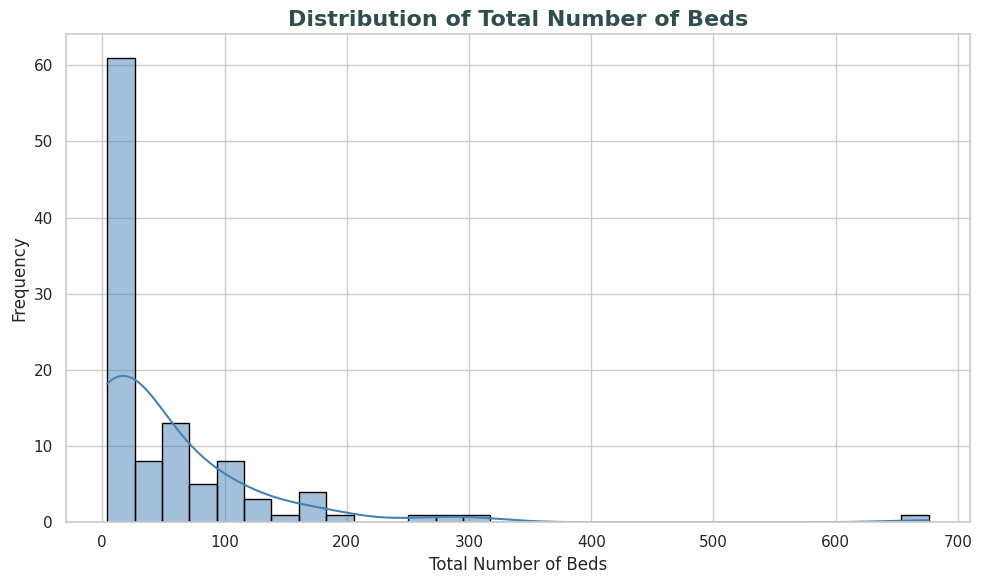

In [41]:
# UNIVARIATE ANALYSIS
# Visualization 1: Histogram + KDE
# Distribution of Total Number of Beds
# Shows skewness and spread of bed counts
# across 108 valid hospital records

beds_only = df_cleaned["total_number_beds"].dropna()
plt.figure(figsize=(10, 6))
ax = sns.histplot(beds_only, kde=True, bins=30, edgecolor="black", color="steelblue")
ax.set_title("Distribution of Total Number of Beds", fontsize=16, fontweight="bold", color="darkslategray")
ax.set_xlabel("Total Number of Beds", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.grid(True)
plt.tight_layout()
plt.show()

**Distribution of Total Number of Beds:**

The total_number_beds distribution is highly right-skewed with a skewness of 4.23, meaning most hospitals have a low bed count. The majority of facilities cluster below 100 beds, while a few large hospitals extend up to 676 beds. The KDE curve confirms this right skew — a steep rise at lower values and a long tail toward higher bed counts. This is consistent with our statistical analysis where mean (53.14) is significantly higher than median (17.50).

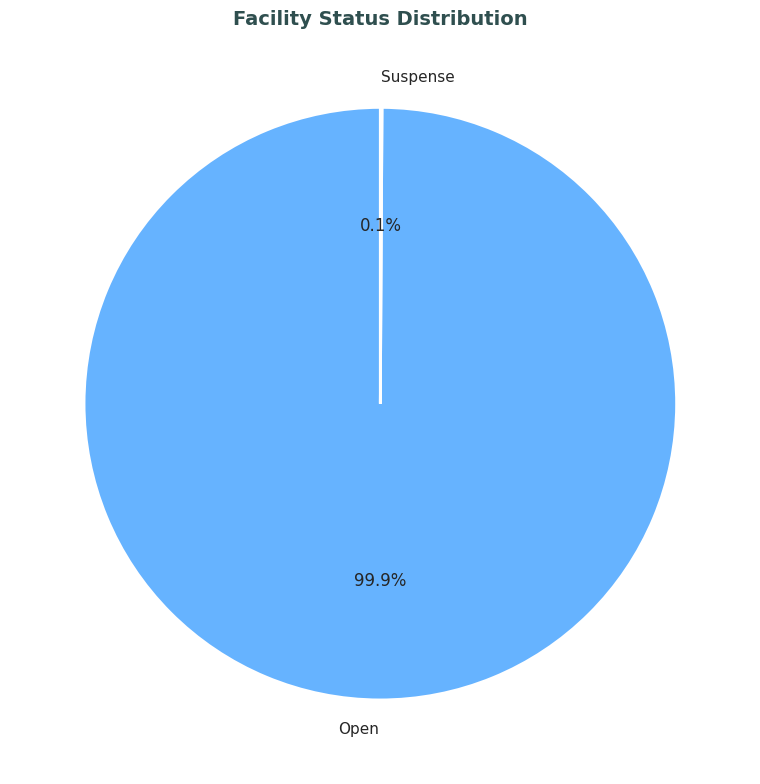

In [42]:
# Visualization 2: Pie Chart
# Facility Status Distribution
# Shows % share of Open/Closed/Suspended facilities

facility_status = df_cleaned["facility_status_desc"].value_counts()
colors = ["#66b3ff", "#ff9999", "#99ff99", "#ffcc99"]
plt.figure(figsize=(8, 8))
plt.pie(facility_status.values, labels=facility_status.index, colors=colors, autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
plt.title("Facility Status Distribution", fontsize=14, fontweight="bold", color="darkslategray")
plt.tight_layout()
plt.show()

**Facility Status Distribution:**

The facility status distribution shows that 99.9% of California licensed healthcare facilities are currently Open, with only 0.1% in Suspense status. This indicates a highly active and operational healthcare network across the state.

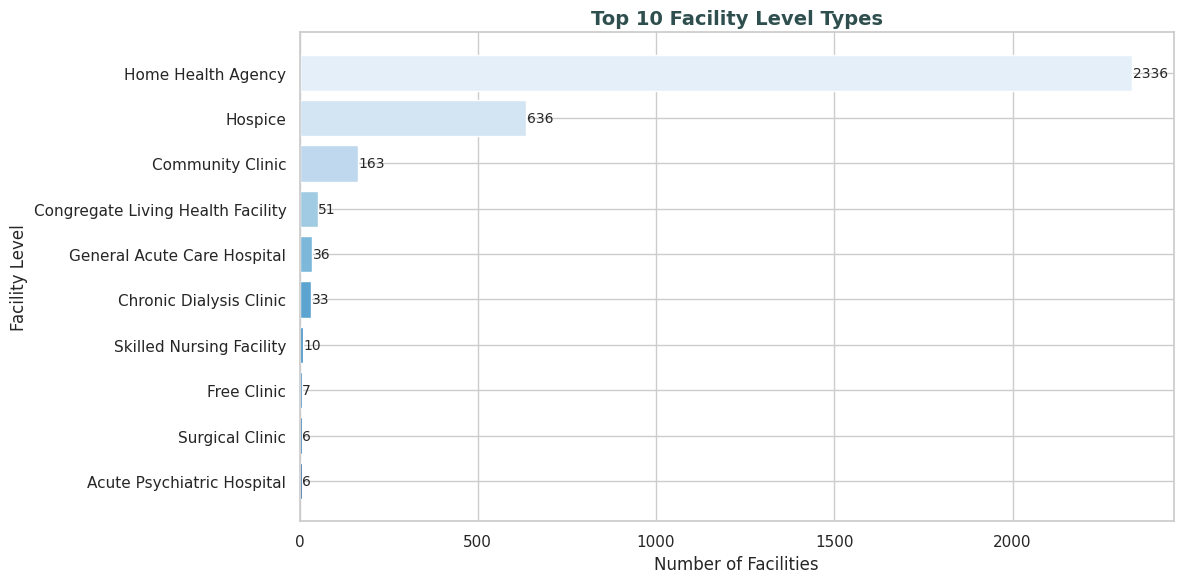

In [43]:
# Visualization 3: Bar Chart
# Top 10 Facility Level Types
# Shows which facility types are most common
top_facility = (df_cleaned["facility_level_desc"].value_counts().head(10).sort_values(ascending=True))
plt.figure(figsize=(12, 6))
plt.rcParams["axes.prop_cycle"] = plt.cycler(
    color=sns.color_palette("Set2"))
bars = plt.barh(top_facility.index,top_facility.values,color=sns.color_palette("Blues_r", n_colors=len(top_facility)))
plt.title("Top 10 Facility Level Types", fontsize=14, fontweight="bold", color="darkslategray")
plt.xlabel("Number of Facilities", fontsize=12)
plt.ylabel("Facility Level", fontsize=12)
# Show count on each bar
for i, v in enumerate(top_facility.values):
    plt.text(v + 1, i, str(v),
             va="center", fontsize=10)

plt.tight_layout()
plt.show()

**Top 10 Facility Level Types:**

The top 10 facility level types show that Home Health Agency dominates with 2,336 facilities — significantly higher than all other types. Hospice follows with 636 facilities, and Community Clinic with 163. General Acute Care Hospitals account for only 36 facilities, confirming that most California licensed healthcare facilities are home-based and outpatient care centers rather than inpatient hospitals. This also explains why 96.72% of facilities have no beds.

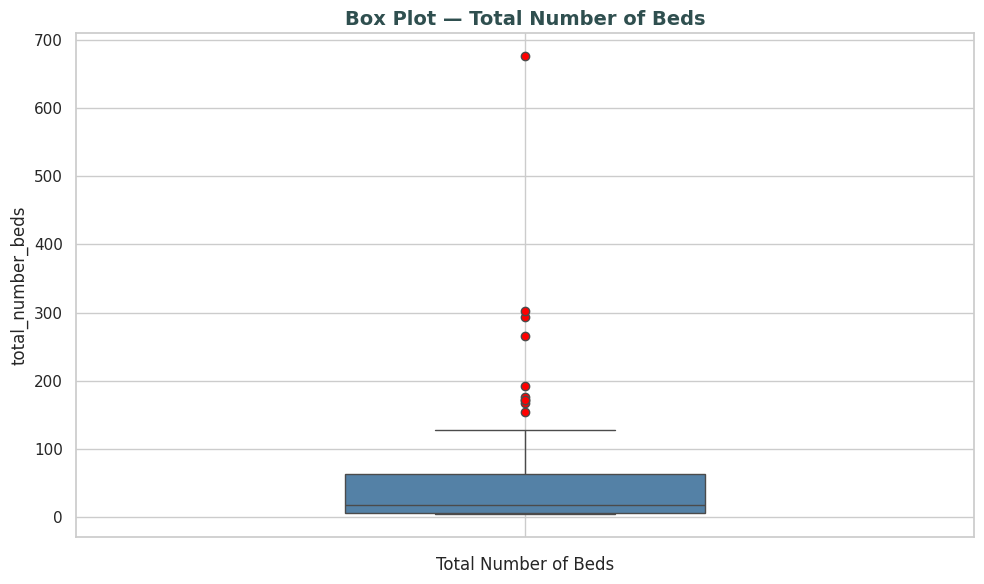

In [44]:
# Visualization 4: Box Plot
# Total Number of Beds — Outlier Detection
# Shows spread, median and extreme outliers
beds_only = df_cleaned["total_number_beds"].dropna()

plt.figure(figsize=(10, 6))
sns.boxplot(y=beds_only, color="steelblue", width=0.4, flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 6})
plt.title("Box Plot — Total Number of Beds", fontsize=14, fontweight="bold", color="darkslategray")
plt.xlabel("Total Number of Beds", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

**Total Number of Beds — Outlier Detection:**

The box plot reveals a heavily right-skewed distribution of bed counts across 108 valid hospital records. The interquartile range (IQR) is compressed between 6 and 80 beds, indicating most hospitals have a relatively low bed count. The median line sits close to the left edge of the box, confirming the right skew. Multiple red outlier points are visible beyond 150 beds, with one extreme outlier at 676 beds — a single large hospital significantly separated from the rest. This is consistent with the skewness of 4.23 and kurtosis of 25.39 identified in the statistical analysis.

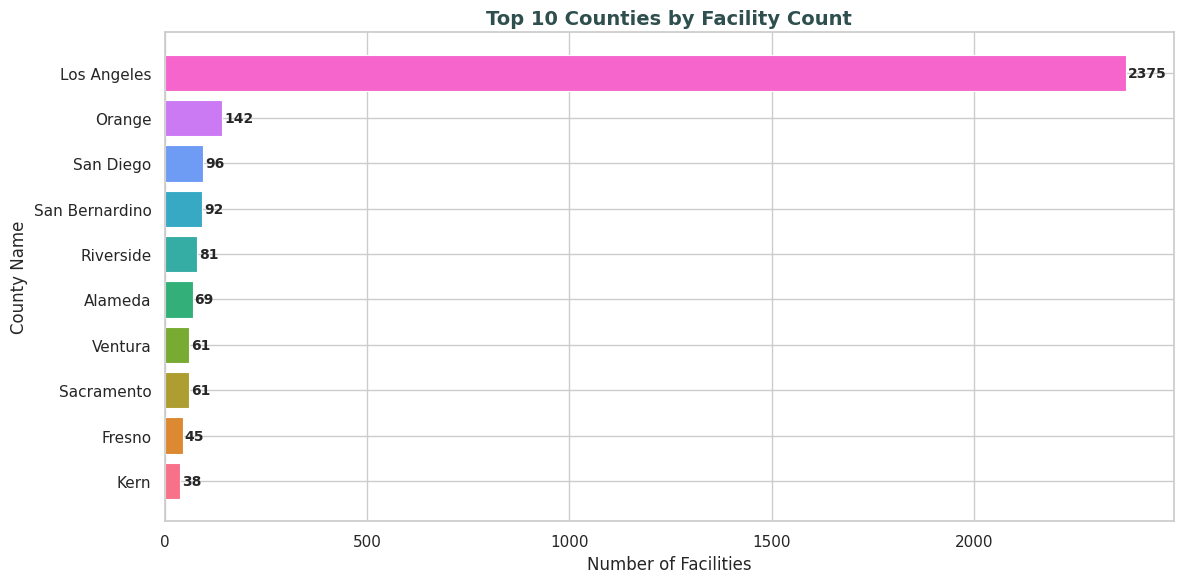

In [45]:
# Bivariate Analysis:
# Visualization 5: Horizontal Bar Chart
# Top 10 Counties by Facility Count
# Bivariate — County Name vs Facility Count

top_counties = (df_cleaned["county_name"].value_counts().head(10).sort_values(ascending=True))
plt.figure(figsize=(12, 6))
colors = sns.color_palette("husl", n_colors=len(top_counties))
plt.barh(top_counties.index, top_counties.values, color=colors, edgecolor="white", linewidth=0.8)
plt.title("Top 10 Counties by Facility Count", fontsize=14, fontweight="bold", color="darkslategray")
plt.xlabel("Number of Facilities", fontsize=12)
plt.ylabel("County Name", fontsize=12)

for i, v in enumerate(top_counties.values):
    plt.text(v + 5, i, str(v), va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()


**Top 10 Counties by Facility Count:**

The bivariate analysis of county name versus facility count reveals that Los Angeles county dominates with 2,375 facilities — nearly 16 times more than Orange county (142). This reflects Los Angeles being the most populous county in California. San Diego (96), San Bernardino (92), and Riverside (81) follow — all densely populated Southern California counties. Northern California counties like Alameda (69) and Sacramento (61) show moderate facility counts.

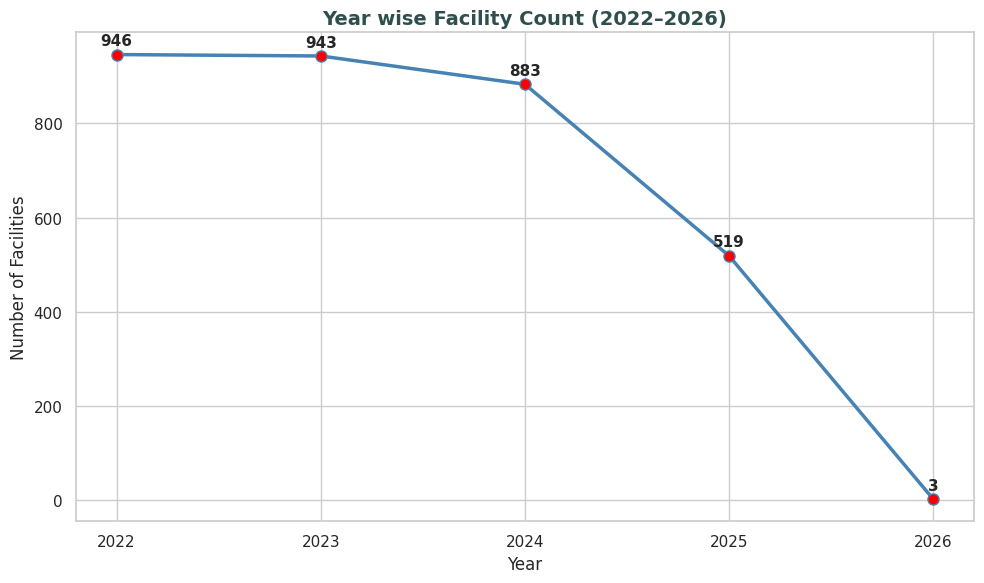

In [46]:
# Visualization 6: Line Chart
# Year wise Facility Count (2022-2026)
# Bivariate — Year vs Number of Facilities

year_counts = (df_cleaned["year"].value_counts().sort_index())
plt.figure(figsize=(10, 6))
plt.plot(year_counts.index, year_counts.values, marker="o", color="steelblue", linewidth=2.5, markersize=8, markerfacecolor="red")
# Show count on each point
for x, y in zip(year_counts.index, year_counts.values):
    plt.text(x, y + 20, str(y),
             ha="center", fontsize=11,
             fontweight="bold")

plt.title("Year wise Facility Count (2022–2026)", fontsize=14, fontweight="bold", color="darkslategray")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Facilities", fontsize=12)
plt.xticks(year_counts.index)
plt.grid(True)
plt.tight_layout()
plt.show()

**Year wise Facility Count (2022-2026):**

The year-wise facility count shows a declining trend from 2022 to 2026. Facility licensing peaked in 2022 with 946 records, remained stable in 2023 (943), then declined to 883 in 2024 and dropped further to 519 in 2025. Only 3 facilities are recorded in January 2026. This decreasing trend may indicate slower licensing activity in recent years or a data reporting lag for the most recent period.

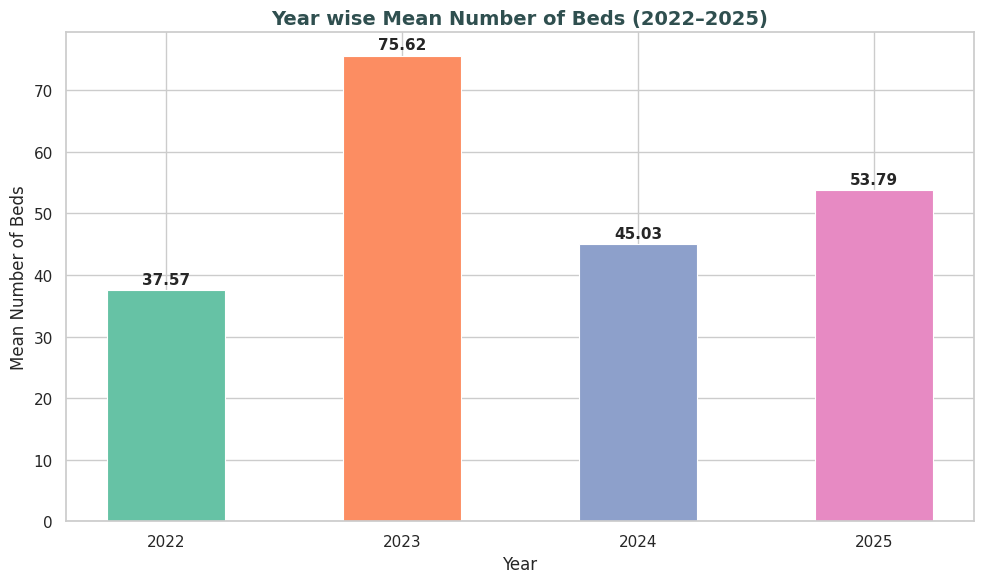

In [47]:
# Visualization 7: Bar Chart
# Year wise Mean Number of Beds (2022–2025)
# Bivariate — Year vs Mean Bed Count

year_beds = (df_cleaned.groupby("year")["total_number_beds"].mean().dropna().round(2))

plt.figure(figsize=(10, 6))
colors = sns.color_palette("Set2", n_colors=len(year_beds))
bars = plt.bar(year_beds.index, year_beds.values, color=colors,edgecolor="white",linewidth=0.8,width=0.5)
for bar, v in zip(bars, year_beds.values):   # bar = single bar object (2022 bar, 2023 bar...), # value = number to display (150.25, 162.80...)
    # Position text at CENTER of this bar + slightly above top
    x_positions = bar.get_x() + bar.get_width() /2
    y_positions = bar.get_height() + 1
    plt.text(x_positions, y_positions, str(v), ha="center", fontsize=11, fontweight="bold")
plt.title("Year wise Mean Number of Beds (2022–2025)", fontsize=14, fontweight="bold", color="darkslategray")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Mean Number of Beds", fontsize=12)
plt.xticks(year_beds.index)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

**Year wise Mean Number of Beds (2022–2025):**

The year-wise mean bed count shows significant variation across years. 2023 recorded the highest mean of 75.62 beds — suggesting large hospitals were licensed that year. 2022 shows the lowest mean of 37.57, while 2024 and 2025 show moderate means of 45.03 and 53.79 respectively. The fluctuating mean across years confirms that a few high-capacity hospitals in specific years are driving the average — consistent with the right-skewed distribution identified earlier.

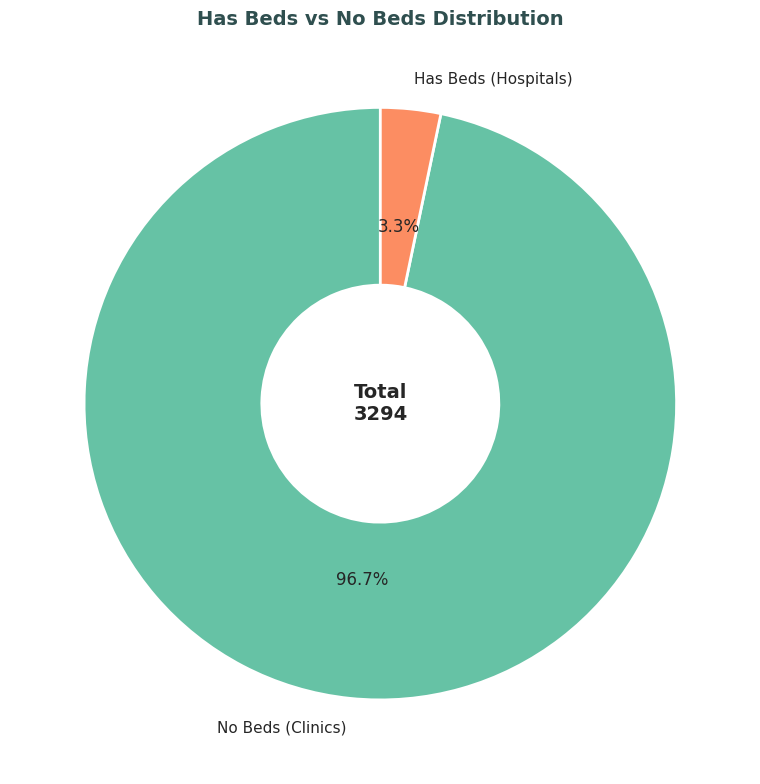

In [48]:
# Visualization 8: Donut Chart
# Has Beds vs No Beds Distribution
# Bivariate — Facility Type vs Bed Availability

beds_dist = df_cleaned["has_beds"].value_counts()
labels = ["No Beds (Clinics)", "Has Beds (Hospitals)"]
colors = sns.color_palette("Set2", n_colors=2)
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(beds_dist.values, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2, "width": 0.6})

# Center text
plt.text(0, 0, f"Total\n{beds_dist.sum()}",ha="center", va="center",fontsize=14, fontweight="bold")
plt.title("Has Beds vs No Beds Distribution",fontsize=14, fontweight="bold", color="darkslategray")
plt.tight_layout()
plt.show()

**Has Beds vs No Beds Distribution:**

The donut chart shows that 96.7% of California licensed healthcare facilities (3,186) have no beds — primarily home health agencies, hospices, and community clinics. Only 3.3% (108 facilities) have beds — representing hospitals and inpatient care centers. The total of 3,294 facilities is displayed at the center. This distribution confirms that California's licensed healthcare network is predominantly outpatient and community-based rather than inpatient.

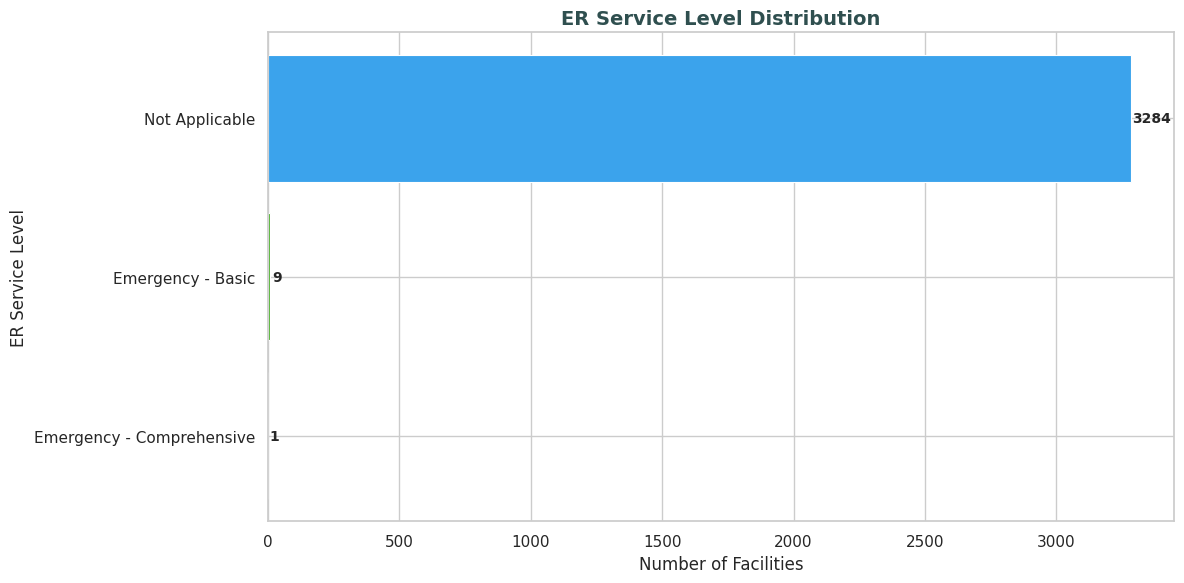

In [49]:
# Visualization 9: Horizontal Bar Chart
# ER Service Level Distribution
# Bivariate — ER Level vs Facility Count
er_counts = (df_cleaned["er_service_level_desc"].value_counts().sort_values(ascending=True))

plt.figure(figsize=(12, 6))
colors = sns.color_palette("husl",n_colors=len(er_counts))
plt.barh(er_counts.index,er_counts.values,color=colors,edgecolor="white",linewidth=0.8)
plt.title("ER Service Level Distribution",fontsize=14, fontweight="bold",color="darkslategray")
plt.xlabel("Number of Facilities", fontsize=12)
plt.ylabel("ER Service Level", fontsize=12)

for i, v in enumerate(er_counts.values):
    plt.text(v + 5, i, str(v),va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

**ER Service Level Distribution:**

The ER service level distribution shows that 3,284 facilities (99.7%) are marked 'Not Applicable' — as most are home health agencies, clinics, and hospices that do not provide emergency services. Only 9 facilities offer Basic Emergency and 1 facility offers Comprehensive Emergency care. This highlights that dedicated emergency care is extremely limited within California's licensed healthcare network — most emergency care would fall under unlicensed or separately categorized facilities.

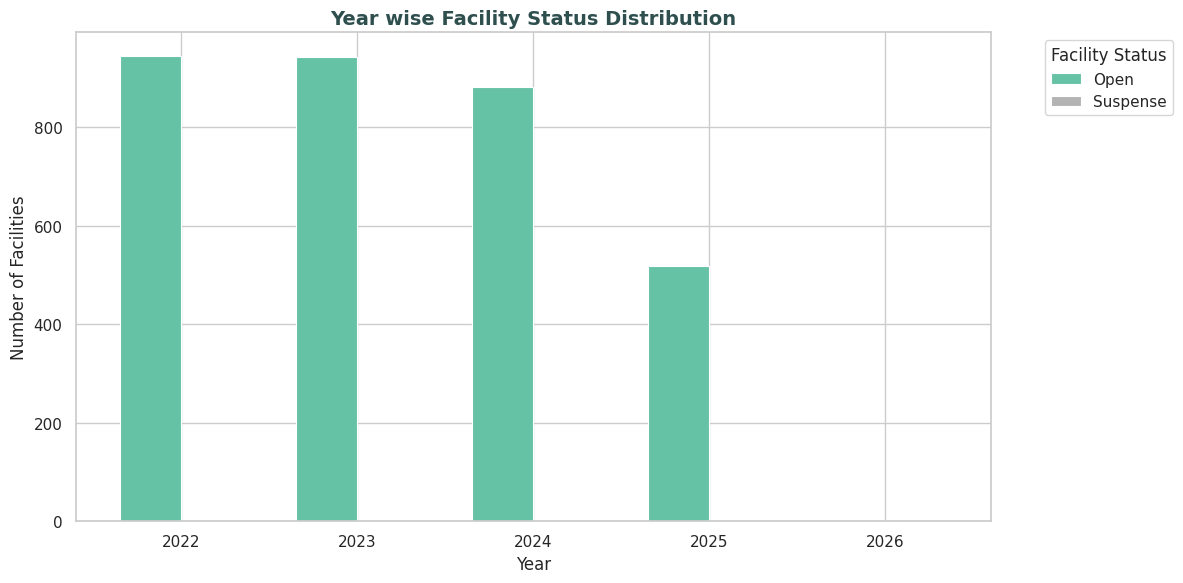

In [50]:
# Visualization 10: Grouped Bar Chart
# Year wise Facility Status Distribution
# Multivariate — Year + Facility Status + Count

year_status = (df_cleaned.groupby(["year", "facility_status_desc"]).size().unstack(fill_value=0))

year_status.plot(kind="bar",figsize=(12, 6),colormap="Set2",edgecolor="white",linewidth=0.8,width=0.7)
plt.title("Year wise Facility Status Distribution",fontsize=14, fontweight="bold",color="darkslategray")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Facilities", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Facility Status", bbox_to_anchor=(1.05, 1),loc="upper left")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

**Year wise Facility Status Distribution:**

The grouped bar chart combines three variables — year, facility status, and count — to reveal how facility licensing activity changed over time. Open facilities dominate across all years, with 2022 and 2023 showing the highest counts (~940 each). A steady decline is visible from 2024 onwards. Suspense status facilities appear as a minimal proportion across all years — confirming that the vast majority of licensed facilities remain actively operational throughout the 2022–2026 period.

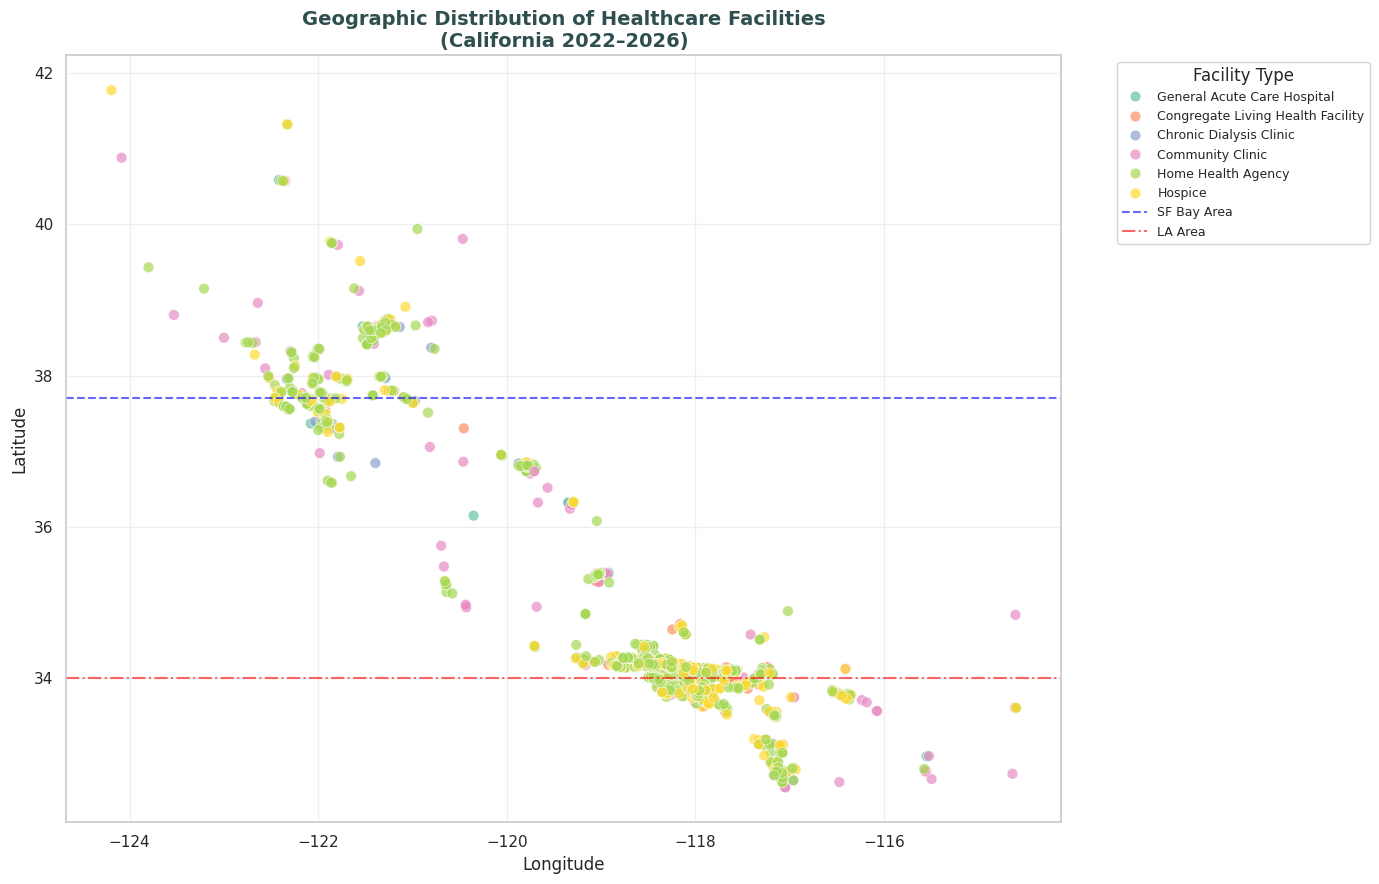

In [51]:
# Visualization 11: Scatter Plot
# Geographic Distribution of Facilities
# Multivariate — Latitude + Longitude + Facility Type

map_data = df_cleaned[df_cleaned["valid_location"] == True]

top_6 = (df_cleaned["facility_level_desc"].value_counts().head(6).index)
map_filtered = map_data[map_data["facility_level_desc"].isin(top_6)]
plt.figure(figsize=(14, 9))
sns.scatterplot(data=map_filtered,x="longitude",y="latitude",hue="facility_level_desc",palette="Set2",alpha=0.7,
    s=60,
    edgecolor="white",
    linewidth=0.5
)
# Different style reference lines
plt.axhline(y=37.7, color="blue",
            linestyle="--",
            linewidth=1.5,
            alpha=0.6,
            label="SF Bay Area")

plt.axhline(y=34.0, color="red",
            linestyle="-.",
            linewidth=1.5,
            alpha=0.6,
            label="LA Area")

plt.title("Geographic Distribution of Healthcare Facilities\n(California 2022–2026)",
          fontsize=14, fontweight="bold",
          color="darkslategray")
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.legend(title="Facility Type",
           bbox_to_anchor=(1.05, 1),
           loc="upper left",
           fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Geographic Distribution of Facilities:**

The scatter plot maps 3,291 valid-coordinate facilities across California. A heavy concentration is visible in Southern California around Los Angeles (LAT 34, LON -118) — consistent with LA having 2,375 facilities. The SF Bay Area reference line (blue) shows a secondary cluster around LAT 37-38. Home Health Agencies and Hospice facilities dominate the geographic spread. Central and rural California show significantly fewer facilities — highlighting potential healthcare access gaps in those regions

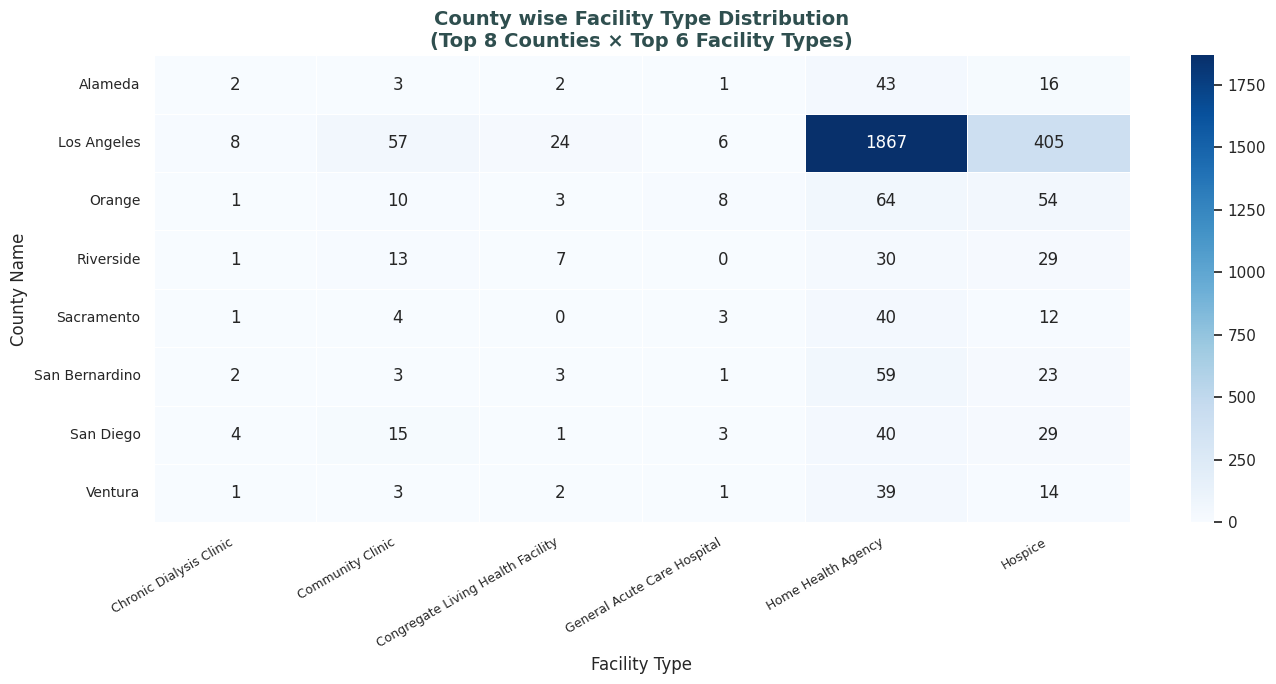

In [52]:
# Visualization 12: Heatmap
# County wise Facility Type Distribution
# Multivariate — County + Facility Type + Count

top_8_counties = (df_cleaned["county_name"].value_counts().head(8).index)
top_6_types = (df_cleaned["facility_level_desc"].value_counts().head(6).index)
heatmap_data = (df_cleaned[
    df_cleaned["county_name"].isin(top_8_counties) &
    df_cleaned["facility_level_desc"].isin(top_6_types)]
    .groupby(["county_name", "facility_level_desc"])
    .size()
    .unstack(fill_value=0))
plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_data,
            annot=True,
            fmt="d",
            cmap="Blues",
            linewidths=0.5,
            linecolor="white")
plt.title("County wise Facility Type Distribution\n(Top 8 Counties × Top 6 Facility Types)",
          fontsize=14, fontweight="bold",
          color="darkslategray")
plt.xlabel("Facility Type", fontsize=12)
plt.ylabel("County Name", fontsize=12)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

**County wise Facility Type Distribution:**

The heatmap combines three variables — county, facility type, and count — to reveal distribution patterns across California. Los Angeles county dominates across all facility types, particularly in Home Health Agencies and Hospice facilities. Orange and San Diego counties show moderate counts in Home Health and Community Clinic categories. Most other counties show minimal representation across facility types — confirming geographic concentration of healthcare services in Southern California. Darker cells indicate higher facility counts, making it easy to identify service gaps across county-facility combinations.

In [53]:
# Dynamic Charts of plotly
# Latitude and longitude of facility Type

import plotly.express as px

map_data = df_cleaned[df_cleaned["valid_location"] == True]
fig = px.scatter(map_data,
    x="longitude",
    y="latitude",
    color="facility_level_desc",
    hover_data=["facility_name",
                "county_name",
                "facility_status_desc",
                "year"],
    size_max=10,
    opacity=0.7,
    title="Interactive Map — California Healthcare Facilities (2022–2026)",
    labels={
        "longitude": "Longitude",
        "latitude": "Latitude",
        "facility_level_desc": "Facility Type"
    }
)

fig.update_layout(
    width=1100,
    height=650,
    legend=dict(
        title="Facility Type",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.01
    )
)

fig.show()

**Interactive Plotly Brief:**

The interactive map allows users to hover over each facility point to view facility name, county, and type. Southern California shows the densest cluster — particularly around Los Angeles and Orange county. The interactive nature enables drill-down exploration of specific facility types across California's geographic regions.

**Stage 4 - Types of Analysis**

In [54]:
# Descriptive Analysis
# What happened? — Summary of dataset
print("=" * 50)
print("DESCRIPTIVE ANALYSIS SUMMARY")
print("=" * 50)

print(f"\nTotal Facilities    : {df_cleaned.shape[0]}")
print(f"Total Columns       : {df_cleaned.shape[1]}")
print(f"Time Period         : 2022 - Jan 2026")
print(f"Counties Covered    : {df_cleaned['county_name'].nunique()}")
print(f"Facility Types      : {df_cleaned['facility_level_desc'].nunique()}")
print(f"Open Facilities     : {df_cleaned[df_cleaned['facility_status_desc']=='Open'].shape[0]}")
print(f"Facilities with Beds: {df_cleaned['has_beds'].sum()}")
print(f"Valid Locations     : {df_cleaned['valid_location'].sum()}")

DESCRIPTIVE ANALYSIS SUMMARY

Total Facilities    : 3294
Total Columns       : 20
Time Period         : 2022 - Jan 2026
Counties Covered    : 44
Facility Types      : 15
Open Facilities     : 3291
Facilities with Beds: 108
Valid Locations     : 3291


In [55]:
# Diagnostic Analysis
# Why did it happen? — Root cause exploration
print("\n--- Why LA Dominates ---")
la_count = df_cleaned[df_cleaned["county_name"] == "Los Angeles"].shape[0]
total = df_cleaned.shape[0]
print(f"LA Facilities  : {la_count}")
print(f"LA Percentage  : {(la_count/total*100):.1f}%")

print("\n--- Declining Trend Analysis ---")
print(df_cleaned["year"].value_counts().sort_index())

print("\n--- Facility Type vs Beds ---")
print(df_cleaned.groupby("facility_level_desc")["has_beds"]
      .sum()
      .sort_values(ascending=False)
      .head(10))


--- Why LA Dominates ---
LA Facilities  : 2375
LA Percentage  : 72.1%

--- Declining Trend Analysis ---
year
2022    946
2023    943
2024    883
2025    519
2026      3
Name: count, dtype: int64

--- Facility Type vs Beds ---
facility_level_desc
Congregate Living Health Facility    51
General Acute Care Hospital          35
Skilled Nursing Facility             10
Acute Psychiatric Hospital            6
Psychiatric Health Facility           4
Hospice Facility                      2
Chronic Dialysis Clinic               0
Free Clinic                           0
Community Clinic                      0
Alternative Birthing Center           0
Name: has_beds, dtype: int64


--- Year wise Trend Prediction ---
2022 Actual : 946
2023 Actual : 943
2024 Actual : 883
2025 Actual : 519
2026 Predicted : 487
2027 Predicted : 353



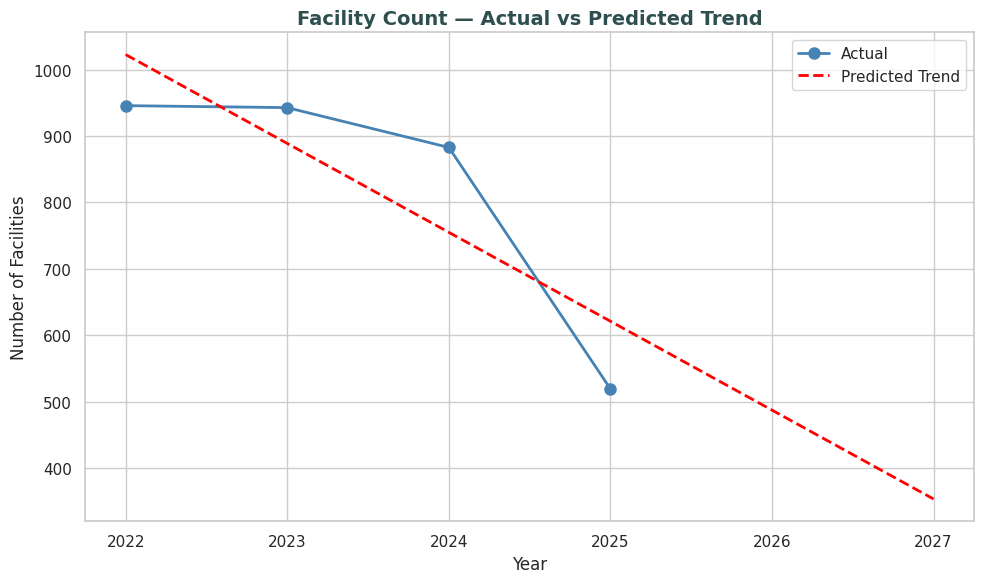

In [56]:
# Predictive Analysis
# What will happen? — Simple trend prediction
import numpy as np

year_counts = (df_cleaned["year"].value_counts().sort_index())

# Remove 2026 — incomplete year
year_counts = year_counts[year_counts.index < 2026]

# Linear trend calculation
z = np.polyfit(year_counts.index, year_counts.values, 1)
p = np.poly1d(z)

print("--- Year wise Trend Prediction ---")
print(f"2022 Actual : {year_counts[2022]}")
print(f"2023 Actual : {year_counts[2023]}")
print(f"2024 Actual : {year_counts[2024]}")
print(f"2025 Actual : {year_counts[2025]}")
print(f"2026 Predicted : {int(p(2026))}")
print(f"2027 Predicted : {int(p(2027))}\n")

# Visualize trend
plt.figure(figsize=(10, 6))
plt.plot(year_counts.index, year_counts.values, marker="o", color="steelblue", linewidth=2, markersize=8, label="Actual")
# Prediction line
pred_years = [2022, 2023, 2024, 2025, 2026, 2027]
plt.plot(pred_years, [int(p(y)) for y in pred_years], linestyle="--", color="red",linewidth=2, label="Predicted Trend")
plt.title("Facility Count — Actual vs Predicted Trend", fontsize=14, fontweight="bold",color="darkslategray")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Facilities", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()